In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/Smart-Warehouse-Delay/

/content/drive/MyDrive/Smart-Warehouse-Delay


In [ ]:
df = pd.read_csv('data/traffic_V6.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249939,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249940,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249941,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249942,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8


#
### **🤖 2. 로봇 / AGV 상태 (Robot)**
* robot_active → 작업 중인 로봇 수
* robot_idle → 대기 중인 로봇 수
* robot_charging → 충전 중인 로봇 수
* robot_utilization → 로봇 활용률
* avg_idle_duration_min → 평균 유휴 시간(분)
* agv_task_success_rate → AGV 작업 성공률
* robot_calibration_score → 로봇 보정 상태 점수

layout_info.csv
* robot_total → 전체 로봇 수

In [ ]:
robot = df[["robot_active","robot_idle","robot_charging","robot_utilization",
        "avg_idle_duration_min","agv_task_success_rate",
        "robot_calibration_score","robot_total"]]
robot

,robot_active,robot_idle,robot_charging,robot_utilization,avg_idle_duration_min,agv_task_success_rate,robot_calibration_score,robot_total
0,9,21,0,0.3000,5.15,0.9109,94.0,30
1,12,18,0,0.4000,3.55,NaN,NaN,30
2,16,14,0,0.5333,2.90,0.8966,86.1,30
3,13,17,0,0.4333,2.58,NaN,93.9,30
4,10,20,0,0.3333,3.25,0.8843,96.8,30
...,...,...,...,...,...,...,...,...
249939,7,71,0,0.0897,14.26,0.8542,NaN,78
249940,12,66,0,0.1538,13.27,0.8753,75.8,78
249941,11,67,0,0.1410,11.01,0.8644,NaN,78
249942,9,69,0,0.1154,13.73,0.8556,68.0,78


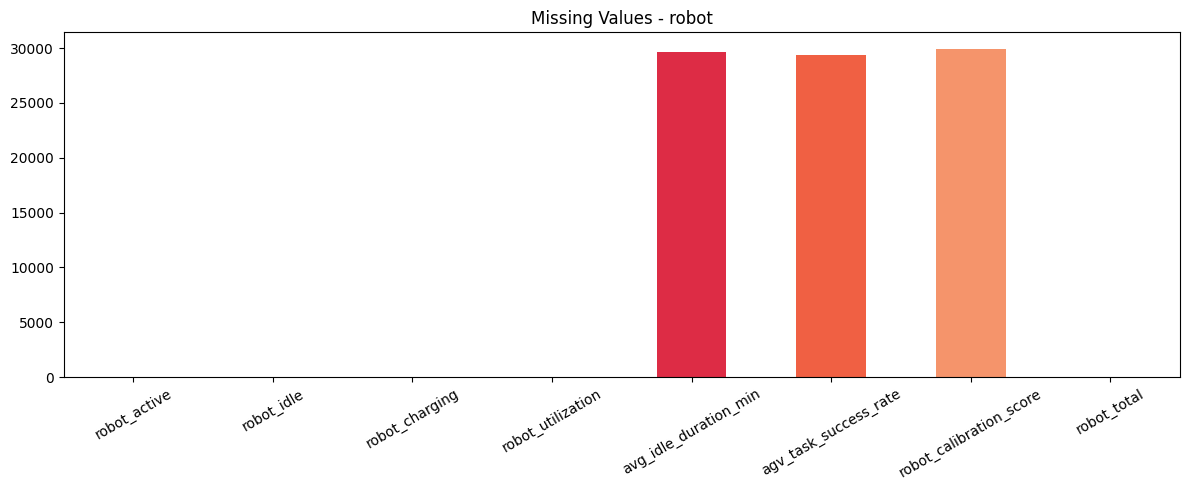

In [ ]:
missing = robot.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - robot')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
robot_active ↔ robot_utilization = **0.76**  
robot_total ↔ robot_idle = **0.72**  
robot_idle ↔ robot_utilization = -0.56  
robot_idle ↔ avg_idle_duration_min = 0.54

In [ ]:
corr = robot.corr()
corr

,robot_active,robot_idle,robot_charging,robot_utilization,avg_idle_duration_min,agv_task_success_rate,robot_calibration_score,robot_total
robot_active,1.000000,-0.219880,-0.078295,0.758631,-0.124243,0.317582,-0.007566,0.276654
robot_idle,-0.219880,1.000000,-0.479411,-0.562777,0.546247,-0.237288,0.014256,0.716371
robot_charging,-0.078295,-0.479411,1.000000,-0.113937,-0.266298,-0.042425,-0.019770,0.033330
robot_utilization,0.758631,-0.562777,-0.113937,1.000000,-0.306617,0.419909,0.000123,-0.277235
avg_idle_duration_min,-0.124243,0.546247,-0.266298,-0.306617,1.000000,-0.132561,-0.006283,0.386432
agv_task_success_rate,0.317582,-0.237288,-0.042425,0.419909,-0.132561,1.000000,0.009068,-0.114640
robot_calibration_score,-0.007566,0.014256,-0.019770,0.000123,-0.006283,0.009068,1.000000,-0.000464
robot_total,0.276654,0.716371,0.033330,-0.277235,0.386432,-0.114640,-0.000464,1.000000


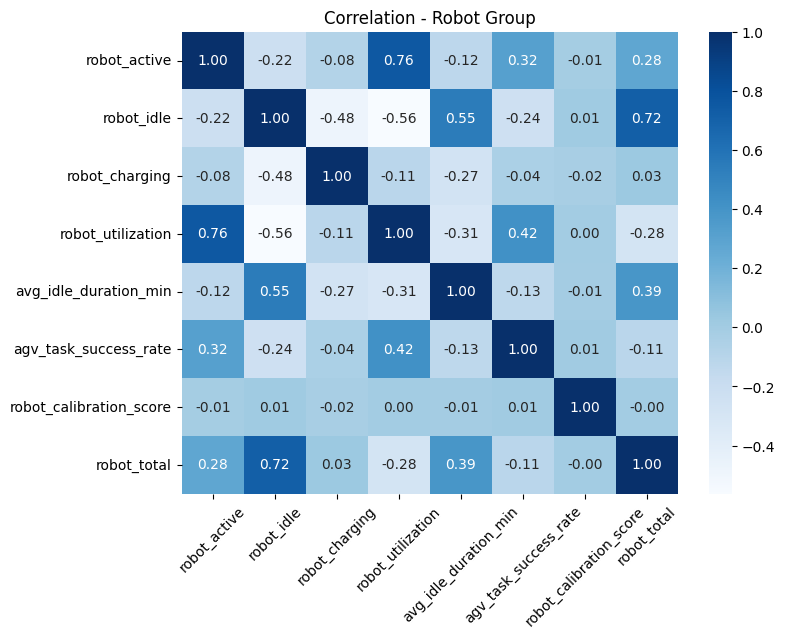

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Robot Group')
plt.xticks(rotation=45)
plt.show()